# 🧠 Notebook 03 - Modelo LSTM

## Tech Challenge 4 - LSTM VALE3

---

### Objetivos deste Notebook:

1. **Entender a arquitetura LSTM** e por que ela funciona para séries temporais
2. **Construir o modelo** usando TensorFlow/Keras
3. **Treinar com early stopping** para evitar overfitting
4. **Avaliar com métricas** (MAE, RMSE, MAPE)
5. **Visualizar previsões** vs valores reais
6. **Salvar o modelo** para deploy

---

### O que é LSTM?

**LSTM (Long Short-Term Memory)** é um tipo especial de rede neural recorrente (RNN) projetada para aprender dependências de longo prazo em sequências.

#### O problema das RNNs tradicionais:

RNNs simples sofrem do problema de **vanishing gradient** — em sequências longas, a informação do início "se perde" durante o treinamento.

```
RNN Simples:
Dia 1 → Dia 2 → Dia 3 → ... → Dia 60
  ↓       ↓       ↓              ↓
Info do Dia 1 vai "sumindo" ao longo da sequência 😢
```

#### A solução do LSTM:

O LSTM tem uma estrutura especial com **3 portões (gates)** que controlam o fluxo de informação:

1. **Forget Gate**: Decide o que esquecer do estado anterior
2. **Input Gate**: Decide o que adicionar de novo
3. **Output Gate**: Decide o que passar para a saída

```
LSTM:
Dia 1 → Dia 2 → Dia 3 → ... → Dia 60
  ↓       ↓       ↓              ↓
Info importante é PRESERVADA através dos portões! 😊
```

## 1. Setup e Carregamento dos Dados

In [9]:
# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Para carregar o scaler
import joblib

import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Verifica GPU (opcional, mas acelera muito o treino)
print("TensorFlow version:", tf.__version__)
print("GPU disponível:", "Sim ✓" if tf.config.list_physical_devices('GPU') else "Não (usando CPU)")
print("\n✓ Bibliotecas importadas com sucesso!")

TensorFlow version: 2.20.0
GPU disponível: Não (usando CPU)

✓ Bibliotecas importadas com sucesso!


In [10]:
# =============================================================================
# CARREGAR DADOS PREPROCESSADOS
# =============================================================================

# Carrega os arrays numpy
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
y_test = np.load('../data/processed/y_test.npy')

# Carrega configuração
with open('../data/processed/config.json', 'r') as f:
    config = json.load(f)

# Carrega o scaler (para desnormalizar depois)
scaler = joblib.load('../models/scaler.joblib')

print("DADOS CARREGADOS")
print("=" * 50)
print(f"\nConjunto de Treino:  X={X_train.shape}, y={y_train.shape}")
print(f"Conjunto de Valid.:  X={X_val.shape}, y={y_val.shape}")
print(f"Conjunto de Teste:   X={X_test.shape}, y={y_test.shape}")
print(f"\nConfiguração:")
print(f"  Janela temporal: {config['janela_temporal']} dias")
print(f"  Input shape: {config['input_shape']}")

DADOS CARREGADOS

Conjunto de Treino:  X=(948, 60, 1), y=(948,)
Conjunto de Valid.:  X=(118, 60, 1), y=(118,)
Conjunto de Teste:   X=(119, 60, 1), y=(119,)

Configuração:
  Janela temporal: 60 dias
  Input shape: [60, 1]


## 2. Arquitetura do Modelo LSTM

### Nossa arquitetura:

```
Input (60 timesteps, 1 feature)
         │
         ▼
┌─────────────────────┐
│   LSTM (50 units)   │  ← Primeira camada: captura padrões básicos
│   return_sequences  │    return_sequences=True para empilhar LSTMs
└─────────────────────┘
         │
         ▼
┌─────────────────────┐
│   Dropout (0.2)     │  ← Regularização: "desliga" 20% dos neurônios
└─────────────────────┘    aleatoriamente para evitar overfitting
         │
         ▼
┌─────────────────────┐
│   LSTM (50 units)   │  ← Segunda camada: padrões mais abstratos
└─────────────────────┘    return_sequences=False (última LSTM)
         │
         ▼
┌─────────────────────┐
│   Dropout (0.2)     │
└─────────────────────┘
         │
         ▼
┌─────────────────────┐
│   Dense (1 unit)    │  ← Saída: um único valor (preço previsto)
└─────────────────────┘
```

---

### Por que essas escolhas?

| Componente | Escolha | Justificativa |
|------------|---------|---------------|
| **Camadas LSTM** | 2 | Uma camada captura padrões simples, duas capturam hierarquias |
| **Units** | 50 | Suficiente para o problema, não muito grande para overfitting |
| **Dropout** | 0.2 (20%) | Regularização padrão, evita overfitting |
| **Ativação final** | Linear (padrão) | Regressão, queremos valores contínuos |
| **Loss** | MSE | Padrão para regressão, penaliza erros grandes |
| **Otimizador** | Adam | Adaptativo, converge bem na maioria dos casos |

In [11]:
# =============================================================================
# HIPERPARÂMETROS DO MODELO
# =============================================================================

# Arquitetura
LSTM_UNITS_1 = 50       # Neurônios na primeira camada LSTM
LSTM_UNITS_2 = 50       # Neurônios na segunda camada LSTM
DROPOUT_RATE = 0.2      # Taxa de dropout (20%)

# Treinamento
EPOCHS = 100            # Máximo de épocas (early stopping vai parar antes)
BATCH_SIZE = 32         # Amostras por batch
LEARNING_RATE = 0.001   # Taxa de aprendizado inicial

# Early Stopping
PATIENCE = 15           # Épocas sem melhoria antes de parar

print("HIPERPARÂMETROS")
print("=" * 50)
print(f"\nArquitetura:")
print(f"  LSTM Layer 1: {LSTM_UNITS_1} units")
print(f"  LSTM Layer 2: {LSTM_UNITS_2} units")
print(f"  Dropout: {DROPOUT_RATE*100:.0f}%")
print(f"\nTreinamento:")
print(f"  Epochs máximo: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Early stopping patience: {PATIENCE}")

HIPERPARÂMETROS

Arquitetura:
  LSTM Layer 1: 50 units
  LSTM Layer 2: 50 units
  Dropout: 20%

Treinamento:
  Epochs máximo: 100
  Batch size: 32
  Learning rate: 0.001
  Early stopping patience: 15


In [12]:
# =============================================================================
# CONSTRUIR O MODELO
# =============================================================================

def criar_modelo_lstm(input_shape, lstm_units_1, lstm_units_2, dropout_rate, learning_rate):
    """
    Cria e compila o modelo LSTM.
    
    Parâmetros:
    -----------
    input_shape : tuple
        Shape da entrada (timesteps, features) = (60, 1)
    lstm_units_1 : int
        Neurônios na primeira camada LSTM
    lstm_units_2 : int
        Neurônios na segunda camada LSTM
    dropout_rate : float
        Taxa de dropout (0 a 1)
    learning_rate : float
        Taxa de aprendizado do otimizador
    
    Retorna:
    --------
    model : keras.Model
        Modelo compilado
    """
    
    model = Sequential([
        # Camada de entrada explícita
        Input(shape=input_shape),
        
        # Primeira camada LSTM
        # return_sequences=True porque vamos empilhar outra LSTM depois
        LSTM(units=lstm_units_1, return_sequences=True),
        
        # Dropout para regularização
        Dropout(dropout_rate),
        
        # Segunda camada LSTM
        # return_sequences=False (padrão) porque é a última LSTM
        LSTM(units=lstm_units_2, return_sequences=False),
        
        # Dropout
        Dropout(dropout_rate),
        
        # Camada de saída
        # 1 neurônio para prever um único valor (preço)
        Dense(units=1)
    ])
    
    # Compila o modelo
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',  # Mean Squared Error - padrão para regressão
        metrics=['mae']  # Mean Absolute Error - mais interpretável
    )
    
    return model

# Cria o modelo
input_shape = tuple(config['input_shape'])  # (60, 1)
modelo = criar_modelo_lstm(input_shape, LSTM_UNITS_1, LSTM_UNITS_2, DROPOUT_RATE, LEARNING_RATE)

print("✓ Modelo criado com sucesso!")

✓ Modelo criado com sucesso!


In [13]:
# =============================================================================
# RESUMO DO MODELO
# =============================================================================

print("ARQUITETURA DO MODELO")
print("=" * 50)
modelo.summary()

ARQUITETURA DO MODELO


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# =============================================================================
# ENTENDENDO OS PARÂMETROS
# =============================================================================

print("EXPLICAÇÃO DOS PARÂMETROS")
print("=" * 50)

print("""
LSTM Layer 1: ~20.400 parâmetros
─────────────────────────────────
Fórmula: 4 * [(input_size + units) * units + units]
       = 4 * [(1 + 50) * 50 + 50]
       = 4 * [2550 + 50]
       = 4 * 2600 = 10.400

O "4" vem dos 4 componentes internos do LSTM:
  - Forget gate
  - Input gate  
  - Cell state candidate
  - Output gate

LSTM Layer 2: ~20.200 parâmetros
─────────────────────────────────
Fórmula: 4 * [(50 + 50) * 50 + 50]
       = 4 * [5000 + 50]
       = 4 * 5050 = 20.200

Dense Layer: 51 parâmetros
─────────────────────────────────
Fórmula: (input_size + 1) * output_size
       = (50 + 1) * 1 = 51
O "+1" é o bias.

Dropout não tem parâmetros treináveis!
Ele apenas "desliga" neurônios aleatoriamente durante o treino.
""")

EXPLICAÇÃO DOS PARÂMETROS

LSTM Layer 1: ~20.400 parâmetros
─────────────────────────────────
Fórmula: 4 * [(input_size + units) * units + units]
       = 4 * [(1 + 50) * 50 + 50]
       = 4 * [2550 + 50]
       = 4 * 2600 = 10.400

O "4" vem dos 4 componentes internos do LSTM:
  - Forget gate
  - Input gate  
  - Cell state candidate
  - Output gate

LSTM Layer 2: ~20.200 parâmetros
─────────────────────────────────
Fórmula: 4 * [(50 + 50) * 50 + 50]
       = 4 * [5000 + 50]
       = 4 * 5050 = 20.200

Dense Layer: 51 parâmetros
─────────────────────────────────
Fórmula: (input_size + 1) * output_size
       = (50 + 1) * 1 = 51
O "+1" é o bias.

Dropout não tem parâmetros treináveis!
Ele apenas "desliga" neurônios aleatoriamente durante o treino.



## 3. Configuração do Treinamento

### Callbacks — O que são?

Callbacks são funções que executam em momentos específicos durante o treinamento:

- **EarlyStopping**: Para o treino se não houver melhoria
- **ModelCheckpoint**: Salva o melhor modelo durante o treino
- **ReduceLROnPlateau**: Reduz o learning rate se estagnar

---

### Early Stopping — Por que usar?

Sem early stopping, o modelo pode:
1. **Overfitting**: Decorar os dados de treino, mas falhar nos novos
2. **Desperdício**: Treinar por mais tempo sem ganho real

```
Loss
  │
  │\                      
  │ \    Treino ────────────────  (continua caindo)
  │  \        
  │   \   Validação ─────╱─────  (começa a subir = overfitting!)
  │    \              ╱
  │     \──────────╱
  │           ↑
  │     Early Stop aqui!
  └─────────────────────────── Épocas
```

In [15]:
# =============================================================================
# CONFIGURAR CALLBACKS
# =============================================================================

# Cria pasta para salvar modelo
os.makedirs('../models', exist_ok=True)

callbacks = [
    # Early Stopping: para se val_loss não melhorar por PATIENCE épocas
    EarlyStopping(
        monitor='val_loss',      # Métrica a monitorar
        patience=PATIENCE,       # Épocas sem melhoria antes de parar
        restore_best_weights=True,  # Restaura pesos do melhor modelo
        verbose=1
    ),
    
    # Model Checkpoint: salva o melhor modelo
    ModelCheckpoint(
        filepath='../models/lstm_vale3_best.keras',
        monitor='val_loss',
        save_best_only=True,     # Só salva se for o melhor até agora
        verbose=1
    ),
    
    # Reduce LR: reduz learning rate se estagnar
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,              # Multiplica LR por 0.5 (reduz pela metade)
        patience=5,              # Espera 5 épocas antes de reduzir
        min_lr=1e-6,             # LR mínimo
        verbose=1
    )
]

print("CALLBACKS CONFIGURADOS")
print("=" * 50)
print("\n1. EarlyStopping:")
print(f"   - Monitora: val_loss")
print(f"   - Paciência: {PATIENCE} épocas")
print(f"   - Restaura melhores pesos: Sim")

print("\n2. ModelCheckpoint:")
print(f"   - Salva em: ../models/lstm_vale3_best.keras")
print(f"   - Salva apenas o melhor: Sim")

print("\n3. ReduceLROnPlateau:")
print(f"   - Fator de redução: 0.5 (divide por 2)")
print(f"   - Paciência: 5 épocas")

CALLBACKS CONFIGURADOS

1. EarlyStopping:
   - Monitora: val_loss
   - Paciência: 15 épocas
   - Restaura melhores pesos: Sim

2. ModelCheckpoint:
   - Salva em: ../models/lstm_vale3_best.keras
   - Salva apenas o melhor: Sim

3. ReduceLROnPlateau:
   - Fator de redução: 0.5 (divide por 2)
   - Paciência: 5 épocas


## 4. Treinamento do Modelo

In [16]:
# =============================================================================
# TREINAR O MODELO
# =============================================================================

print("INICIANDO TREINAMENTO")
print("=" * 50)
print(f"\nEpochs máximo: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Early stopping patience: {PATIENCE}")
print("\n" + "-" * 50)

# Treina o modelo
historico = modelo.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 50)
print("✓ TREINAMENTO CONCLUÍDO!")
print(f"  Épocas executadas: {len(historico.history['loss'])}")

INICIANDO TREINAMENTO

Epochs máximo: 100
Batch size: 32
Early stopping patience: 15

--------------------------------------------------
Epoch 1/100
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0668 - mae: 0.1964
Epoch 1: val_loss improved from None to 0.00564, saving model to ../models/lstm_vale3_best.keras

Epoch 1: finished saving model to ../models/lstm_vale3_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0300 - mae: 0.1235 - val_loss: 0.0056 - val_mae: 0.0644 - learning_rate: 0.0010
Epoch 2/100
27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0065 - mae: 0.0652
Epoch 2: val_loss improved from 0.00564 to 0.00154, saving model to ../models/lstm_vale3_best.keras

Epoch 2: finished saving model to ../models/lstm_vale3_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0061 - mae: 0.0622 - val_loss: 0.0015 - val_mae: 0.0299 - learning_rate: 0.0010
Epoch 3/100
27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0052 - mae: 0.0542
Epoch 3: val_loss improved fr

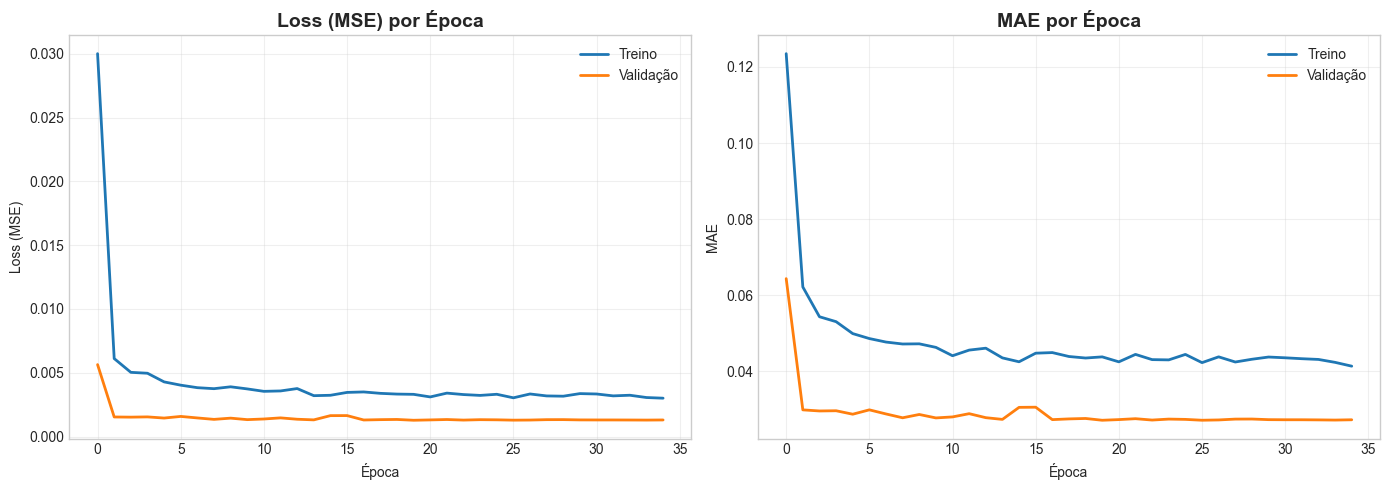

📊 INTERPRETAÇÃO:
   - As curvas de treino e validação devem diminuir juntas
   - Se validação subir enquanto treino cai = OVERFITTING
   - O early stopping para no ponto ótimo antes do overfitting


In [17]:
# =============================================================================
# VISUALIZAR HISTÓRICO DE TREINAMENTO
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(historico.history['loss'], label='Treino', linewidth=2)
axes[0].plot(historico.history['val_loss'], label='Validação', linewidth=2)
axes[0].set_title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(historico.history['mae'], label='Treino', linewidth=2)
axes[1].plot(historico.history['val_mae'], label='Validação', linewidth=2)
axes[1].set_title('MAE por Época', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 INTERPRETAÇÃO:")
print("   - As curvas de treino e validação devem diminuir juntas")
print("   - Se validação subir enquanto treino cai = OVERFITTING")
print("   - O early stopping para no ponto ótimo antes do overfitting")

## 5. Avaliação do Modelo

### Métricas de Avaliação

| Métrica | Fórmula | Interpretação |
|---------|---------|---------------|
| **MAE** | média(\|real - previsto\|) | Erro médio em R$ |
| **RMSE** | √média((real - previsto)²) | Penaliza erros grandes |
| **MAPE** | média(\|real - previsto\|/real) × 100 | Erro percentual |

---

### Como interpretar?

- **MAE = R$ 2,50**: Em média, erramos R$ 2,50 para cima ou para baixo
- **RMSE = R$ 3,00**: Erros grandes pesam mais (RMSE > MAE indica outliers)
- **MAPE = 3%**: Erramos em média 3% do valor real

In [18]:
# =============================================================================
# FAZER PREVISÕES
# =============================================================================

# Previsões nos 3 conjuntos
y_pred_train = modelo.predict(X_train, verbose=0)
y_pred_val = modelo.predict(X_val, verbose=0)
y_pred_test = modelo.predict(X_test, verbose=0)

# Flatten para facilitar cálculos
y_pred_train = y_pred_train.flatten()
y_pred_val = y_pred_val.flatten()
y_pred_test = y_pred_test.flatten()

print("✓ Previsões realizadas!")
print(f"  Treino: {len(y_pred_train)} previsões")
print(f"  Validação: {len(y_pred_val)} previsões")
print(f"  Teste: {len(y_pred_test)} previsões")

✓ Previsões realizadas!
  Treino: 948 previsões
  Validação: 118 previsões
  Teste: 119 previsões


In [19]:
# =============================================================================
# FUNÇÕES DE MÉTRICAS
# =============================================================================

def calcular_metricas(y_real, y_pred, nome_conjunto):
    """
    Calcula MAE, RMSE e MAPE.
    
    Nota: Os valores estão normalizados (0 a 1).
    Para métricas em R$, precisamos desnormalizar.
    """
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    
    # MAPE - evita divisão por zero
    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    
    print(f"\n{nome_conjunto}:")
    print(f"  MAE (normalizado):  {mae:.6f}")
    print(f"  RMSE (normalizado): {rmse:.6f}")
    print(f"  MAPE:               {mape:.2f}%")
    
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

print("MÉTRICAS (valores normalizados)")
print("=" * 50)

metricas_train = calcular_metricas(y_train, y_pred_train, "TREINO")
metricas_val = calcular_metricas(y_val, y_pred_val, "VALIDAÇÃO")
metricas_test = calcular_metricas(y_test, y_pred_test, "TESTE")

MÉTRICAS (valores normalizados)

TREINO:
  MAE (normalizado):  0.036629
  RMSE (normalizado): 0.048815
  MAPE:               13.49%

VALIDAÇÃO:
  MAE (normalizado):  0.027147
  RMSE (normalizado): 0.035756
  MAPE:               17.03%

TESTE:
  MAE (normalizado):  0.036589
  RMSE (normalizado): 0.046266
  MAPE:               7.86%


In [20]:
# =============================================================================
# MÉTRICAS EM REAIS (R$)
# =============================================================================

def desnormalizar(valores):
    """Converte valores normalizados de volta para R$."""
    return scaler.inverse_transform(valores.reshape(-1, 1)).flatten()

# Desnormaliza todos os valores
y_train_reais = desnormalizar(y_train)
y_val_reais = desnormalizar(y_val)
y_test_reais = desnormalizar(y_test)

y_pred_train_reais = desnormalizar(y_pred_train)
y_pred_val_reais = desnormalizar(y_pred_val)
y_pred_test_reais = desnormalizar(y_pred_test)

def calcular_metricas_reais(y_real, y_pred, nome_conjunto):
    """Calcula métricas em R$."""
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    
    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    
    print(f"\n{nome_conjunto}:")
    print(f"  MAE:  R$ {mae:.2f}")
    print(f"  RMSE: R$ {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

print("MÉTRICAS EM REAIS (R$)")
print("=" * 50)

metricas_train_reais = calcular_metricas_reais(y_train_reais, y_pred_train_reais, "TREINO")
metricas_val_reais = calcular_metricas_reais(y_val_reais, y_pred_val_reais, "VALIDAÇÃO")
metricas_test_reais = calcular_metricas_reais(y_test_reais, y_pred_test_reais, "TESTE")

MÉTRICAS EM REAIS (R$)

TREINO:
  MAE:  R$ 1.47
  RMSE: R$ 1.96
  MAPE: 2.61%

VALIDAÇÃO:
  MAE:  R$ 1.09
  RMSE: R$ 1.43
  MAPE: 2.20%

TESTE:
  MAE:  R$ 1.47
  RMSE: R$ 1.86
  MAPE: 2.30%


In [21]:
# =============================================================================
# INTERPRETAÇÃO DAS MÉTRICAS
# =============================================================================

print("\n" + "=" * 60)
print("INTERPRETAÇÃO DOS RESULTADOS")
print("=" * 60)

mae_test = metricas_test_reais['mae']
mape_test = metricas_test_reais['mape']
preco_medio = y_test_reais.mean()

print(f"\n📊 No conjunto de TESTE:")
print(f"   Preço médio real: R$ {preco_medio:.2f}")
print(f"   Erro médio (MAE): R$ {mae_test:.2f}")
print(f"   Erro percentual (MAPE): {mape_test:.2f}%")

print(f"\n🎯 O que isso significa:")
print(f"   Em média, o modelo erra R$ {mae_test:.2f} nas previsões.")
print(f"   Isso representa {mape_test:.2f}% do preço da ação.")

if mape_test < 5:
    print(f"\n✅ MAPE < 5% é considerado EXCELENTE para previsão de ações!")
elif mape_test < 10:
    print(f"\n✓ MAPE < 10% é considerado BOM para previsão de ações.")
else:
    print(f"\n⚠️ MAPE > 10% indica que o modelo precisa de melhorias.")


INTERPRETAÇÃO DOS RESULTADOS

📊 No conjunto de TESTE:
   Preço médio real: R$ 60.74
   Erro médio (MAE): R$ 1.47
   Erro percentual (MAPE): 2.30%

🎯 O que isso significa:
   Em média, o modelo erra R$ 1.47 nas previsões.
   Isso representa 2.30% do preço da ação.

✅ MAPE < 5% é considerado EXCELENTE para previsão de ações!


## 6. Visualização das Previsões

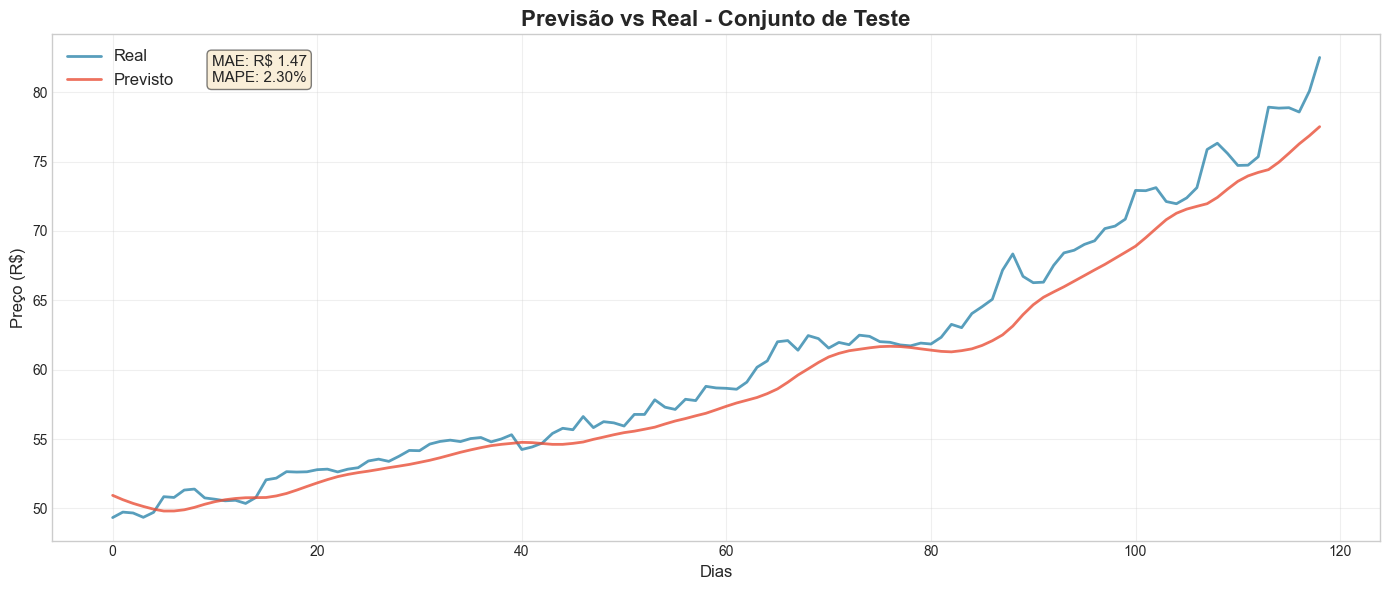

📊 ANÁLISE DO GRÁFICO:
   - A linha vermelha (previsto) deve seguir a azul (real)
   - Quanto mais próximas, melhor o modelo
   - O modelo captura a TENDÊNCIA, mas pode errar valores exatos


In [22]:
# =============================================================================
# GRÁFICO: PREVISÃO VS REAL (TESTE)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

dias = range(len(y_test_reais))

ax.plot(dias, y_test_reais, color='#2E86AB', linewidth=2, label='Real', alpha=0.8)
ax.plot(dias, y_pred_test_reais, color='#E94F37', linewidth=2, label='Previsto', alpha=0.8)

ax.set_title('Previsão vs Real - Conjunto de Teste', fontsize=16, fontweight='bold')
ax.set_xlabel('Dias', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)

# Adiciona métricas no gráfico
textstr = f'MAE: R$ {mae_test:.2f}\nMAPE: {mape_test:.2f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.12, 0.96, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("📊 ANÁLISE DO GRÁFICO:")
print("   - A linha vermelha (previsto) deve seguir a azul (real)")
print("   - Quanto mais próximas, melhor o modelo")
print("   - O modelo captura a TENDÊNCIA, mas pode errar valores exatos")

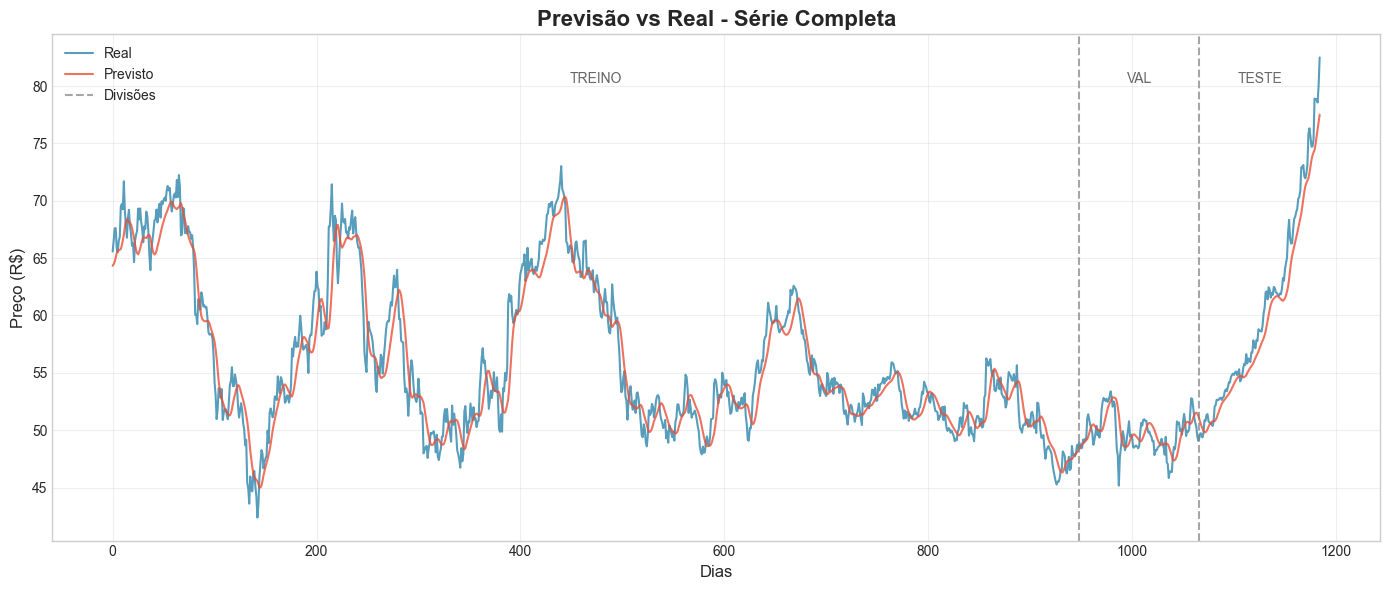

In [23]:
# =============================================================================
# GRÁFICO: SÉRIE COMPLETA COM DIVISÕES
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Concatena todos os valores reais e previstos
todos_reais = np.concatenate([y_train_reais, y_val_reais, y_test_reais])
todos_previstos = np.concatenate([y_pred_train_reais, y_pred_val_reais, y_pred_test_reais])

# Índices
n_train = len(y_train_reais)
n_val = len(y_val_reais)
n_test = len(y_test_reais)

# Plot
ax.plot(todos_reais, color='#2E86AB', linewidth=1.5, label='Real', alpha=0.8)
ax.plot(todos_previstos, color='#E94F37', linewidth=1.5, label='Previsto', alpha=0.8)

# Linhas verticais para marcar divisões
ax.axvline(x=n_train, color='gray', linestyle='--', alpha=0.7, label='Divisões')
ax.axvline(x=n_train + n_val, color='gray', linestyle='--', alpha=0.7)

# Anotações
ax.text(n_train/2, ax.get_ylim()[1]*0.95, 'TREINO', ha='center', fontsize=10, alpha=0.7)
ax.text(n_train + n_val/2, ax.get_ylim()[1]*0.95, 'VAL', ha='center', fontsize=10, alpha=0.7)
ax.text(n_train + n_val + n_test/2, ax.get_ylim()[1]*0.95, 'TESTE', ha='center', fontsize=10, alpha=0.7)

ax.set_title('Previsão vs Real - Série Completa', fontsize=16, fontweight='bold')
ax.set_xlabel('Dias', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

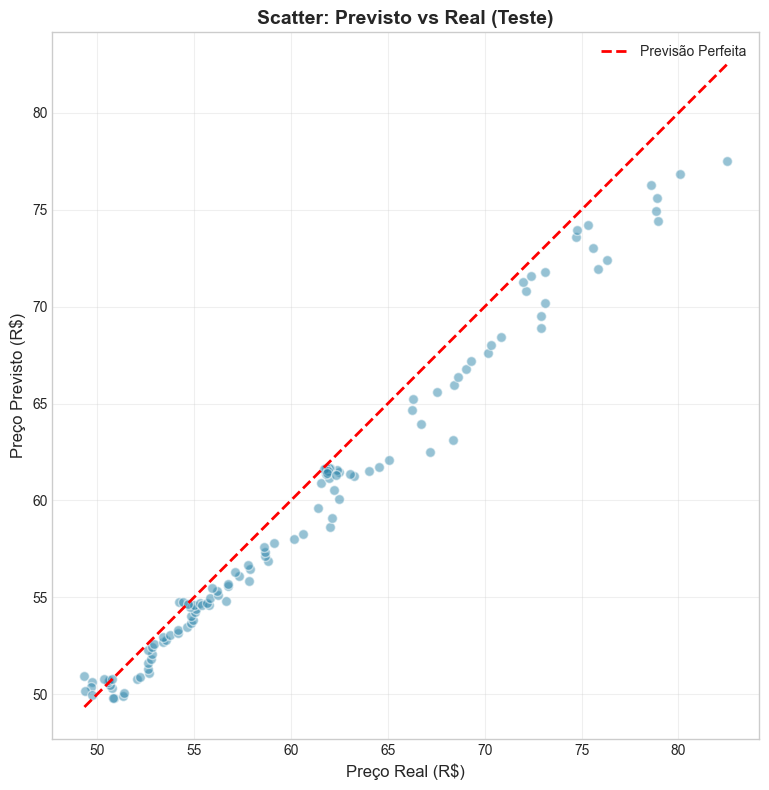

📊 INTERPRETAÇÃO:
   - Pontos próximos da linha vermelha = previsões boas
   - Pontos distantes = erros maiores
   - Quanto mais 'concentrado' na diagonal, melhor o modelo


In [24]:
# =============================================================================
# GRÁFICO: SCATTER PLOT (PREVISTO VS REAL)
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
ax.scatter(y_test_reais, y_pred_test_reais, alpha=0.5, color='#2E86AB', edgecolors='white', s=50)

# Linha de previsão perfeita (y = x)
min_val = min(y_test_reais.min(), y_pred_test_reais.min())
max_val = max(y_test_reais.max(), y_pred_test_reais.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsão Perfeita')

ax.set_title('Scatter: Previsto vs Real (Teste)', fontsize=14, fontweight='bold')
ax.set_xlabel('Preço Real (R$)', fontsize=12)
ax.set_ylabel('Preço Previsto (R$)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Força aspecto quadrado
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("📊 INTERPRETAÇÃO:")
print("   - Pontos próximos da linha vermelha = previsões boas")
print("   - Pontos distantes = erros maiores")
print("   - Quanto mais 'concentrado' na diagonal, melhor o modelo")

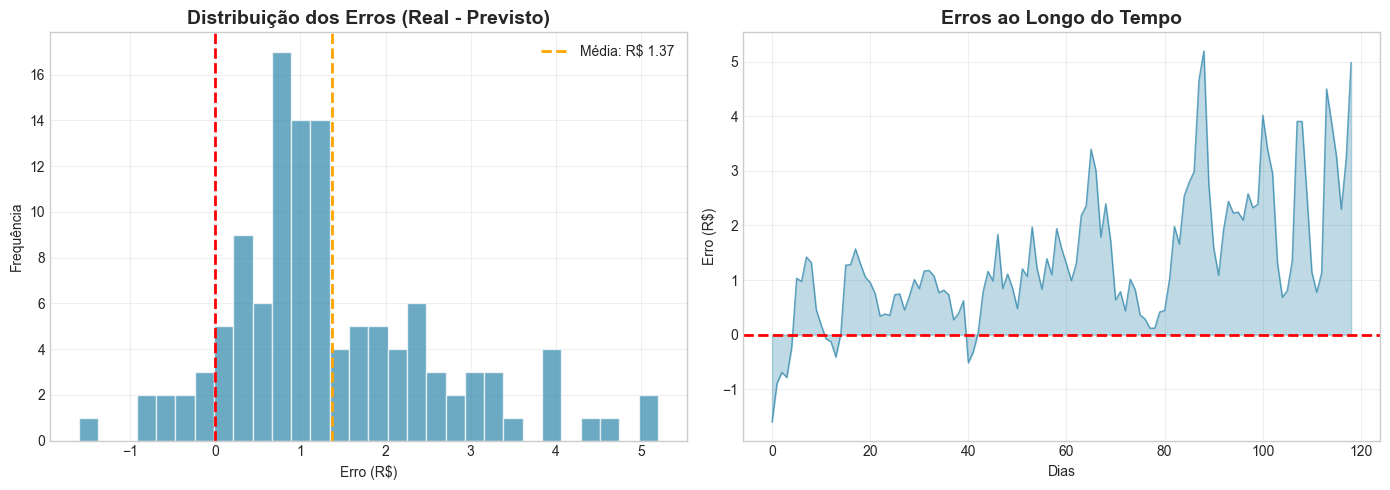

📊 ANÁLISE DOS ERROS:
   Erro médio: R$ 1.37 (idealmente próximo de 0)
   Desvio padrão: R$ 1.25
   Erro máximo: R$ 5.20
   Erro mínimo: R$ -1.60


In [25]:
# =============================================================================
# GRÁFICO: DISTRIBUIÇÃO DOS ERROS
# =============================================================================

erros = y_test_reais - y_pred_test_reais

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma dos erros
axes[0].hist(erros, bins=30, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].axvline(erros.mean(), color='orange', linestyle='--', linewidth=2, label=f'Média: R$ {erros.mean():.2f}')
axes[0].set_title('Distribuição dos Erros (Real - Previsto)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Erro (R$)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Erros ao longo do tempo
axes[1].plot(erros, color='#2E86AB', linewidth=1, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].fill_between(range(len(erros)), erros, 0, alpha=0.3, color='#2E86AB')
axes[1].set_title('Erros ao Longo do Tempo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dias')
axes[1].set_ylabel('Erro (R$)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 ANÁLISE DOS ERROS:")
print(f"   Erro médio: R$ {erros.mean():.2f} (idealmente próximo de 0)")
print(f"   Desvio padrão: R$ {erros.std():.2f}")
print(f"   Erro máximo: R$ {erros.max():.2f}")
print(f"   Erro mínimo: R$ {erros.min():.2f}")

## 7. Salvar o Modelo

In [26]:
# =============================================================================
# SALVAR MODELO FINAL
# =============================================================================

# Salva o modelo completo (arquitetura + pesos)
modelo.save('../models/lstm_vale3.h5')

print("MODELO SALVO em formato H5")
print("=" * 50)
print("\nArquivos gerados:")
print("  ../models/lstm_vale3.keras       ← Modelo final")
print("  ../models/lstm_vale3_best.keras  ← Melhor modelo durante treino")
print("  ../models/scaler.joblib          ← Scaler para normalização")

MODELO SALVO em formato H5

Arquivos gerados:
  ../models/lstm_vale3.keras       ← Modelo final
  ../models/lstm_vale3_best.keras  ← Melhor modelo durante treino
  ../models/scaler.joblib          ← Scaler para normalização


In [27]:
# =============================================================================
# SALVAR MÉTRICAS
# =============================================================================

metricas_finais = {
    'treino': {
        'mae_normalizado': float(metricas_train['mae']),
        'rmse_normalizado': float(metricas_train['rmse']),
        'mape': float(metricas_train['mape']),
        'mae_reais': float(metricas_train_reais['mae']),
        'rmse_reais': float(metricas_train_reais['rmse'])
    },
    'validacao': {
        'mae_normalizado': float(metricas_val['mae']),
        'rmse_normalizado': float(metricas_val['rmse']),
        'mape': float(metricas_val['mape']),
        'mae_reais': float(metricas_val_reais['mae']),
        'rmse_reais': float(metricas_val_reais['rmse'])
    },
    'teste': {
        'mae_normalizado': float(metricas_test['mae']),
        'rmse_normalizado': float(metricas_test['rmse']),
        'mape': float(metricas_test['mape']),
        'mae_reais': float(metricas_test_reais['mae']),
        'rmse_reais': float(metricas_test_reais['rmse'])
    },
    'hiperparametros': {
        'lstm_units_1': LSTM_UNITS_1,
        'lstm_units_2': LSTM_UNITS_2,
        'dropout_rate': DROPOUT_RATE,
        'epochs_executados': len(historico.history['loss']),
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE
    }
}

with open('../models/metricas.json', 'w') as f:
    json.dump(metricas_finais, f, indent=2)

print("✓ Métricas salvas em: ../models/metricas.json")

✓ Métricas salvas em: ../models/metricas.json


In [28]:
# =============================================================================
# TESTE DE CARREGAMENTO
# =============================================================================

print("TESTE DE CARREGAMENTO DO MODELO")
print("=" * 50)

# Carrega o modelo salvo
modelo_carregado = tf.keras.models.load_model('../models/lstm_vale3.keras')

# Faz uma previsão de teste
previsao_teste = modelo_carregado.predict(X_test[:1], verbose=0)
previsao_teste_reais = desnormalizar(previsao_teste.flatten())

print(f"\n✓ Modelo carregado com sucesso!")
print(f"\nTeste de previsão:")
print(f"  Entrada: sequência de {X_test[0].shape[0]} dias")
print(f"  Previsão: R$ {previsao_teste_reais[0]:.2f}")
print(f"  Valor real: R$ {y_test_reais[0]:.2f}")

TESTE DE CARREGAMENTO DO MODELO

✓ Modelo carregado com sucesso!

Teste de previsão:
  Entrada: sequência de 60 dias
  Previsão: R$ 50.64
  Valor real: R$ 49.34


## 8. Resumo e Próximos Passos

In [29]:
# =============================================================================
# RESUMO FINAL
# =============================================================================

print("=" * 60)
print("RESUMO DO MODELO LSTM")
print("=" * 60)

print(f"\n🧠 ARQUITETURA:")
print(f"   LSTM Layer 1: {LSTM_UNITS_1} units")
print(f"   LSTM Layer 2: {LSTM_UNITS_2} units")
print(f"   Dropout: {DROPOUT_RATE*100:.0f}%")
print(f"   Total de parâmetros: {modelo.count_params():,}")

print(f"\n📈 TREINAMENTO:")
print(f"   Épocas executadas: {len(historico.history['loss'])}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Early stopping: Sim (patience={PATIENCE})")

print(f"\n📊 MÉTRICAS NO TESTE:")
print(f"   MAE:  R$ {metricas_test_reais['mae']:.2f}")
print(f"   RMSE: R$ {metricas_test_reais['rmse']:.2f}")
print(f"   MAPE: {metricas_test_reais['mape']:.2f}%")

print(f"\n💾 ARQUIVOS GERADOS:")
print(f"   ../models/lstm_vale3.keras")
print(f"   ../models/lstm_vale3_best.keras")
print(f"   ../models/metricas.json")

print("\n" + "=" * 60)
print("PRÓXIMO PASSO: Notebook 04 - Deploy da API")
print("=" * 60)
print("\nNo próximo notebook vamos:")
print("  1. Criar a API com FastAPI")
print("  2. Implementar endpoint de previsão")
print("  3. Testar localmente")
print("  4. Preparar para deploy na AWS")

RESUMO DO MODELO LSTM

🧠 ARQUITETURA:
   LSTM Layer 1: 50 units
   LSTM Layer 2: 50 units
   Dropout: 20%
   Total de parâmetros: 30,651

📈 TREINAMENTO:
   Épocas executadas: 35
   Batch size: 32
   Early stopping: Sim (patience=15)

📊 MÉTRICAS NO TESTE:
   MAE:  R$ 1.47
   RMSE: R$ 1.86
   MAPE: 2.30%

💾 ARQUIVOS GERADOS:
   ../models/lstm_vale3.keras
   ../models/lstm_vale3_best.keras
   ../models/metricas.json

PRÓXIMO PASSO: Notebook 04 - Deploy da API

No próximo notebook vamos:
  1. Criar a API com FastAPI
  2. Implementar endpoint de previsão
  3. Testar localmente
  4. Preparar para deploy na AWS
